In [1]:
import os, sys, json, shutil, traceback, subprocess, spm, gzip, shutil
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from spm import Struct, spm_realign, spm_reslice

In [2]:
## Pre-Defs

WORK_NAME = "M01_ds003768"

# Dirs
DATA_ROOT = Path("/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768")
RESULTS_ROOT = DATA_ROOT.parent / "rsCVR_Results"
WORK_ROOT = RESULTS_ROOT / WORK_NAME
INDEX_DIR = WORK_ROOT / "index"
LOG_DIR = WORK_ROOT / "logs"
QC_DIR = WORK_ROOT / "qc"
RAPIDTIDE_DIR = WORK_ROOT / "rapidtide"
SPM_DIR = WORK_ROOT / "spm_preproc"
SUMMARY_DIR = WORK_ROOT / "summary"
MANIFEST_DIR = WORK_ROOT / "manifests"

for d in [RESULTS_ROOT, WORK_ROOT, INDEX_DIR, LOG_DIR, QC_DIR, RAPIDTIDE_DIR, SPM_DIR, SUMMARY_DIR, MANIFEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("WORK_ROOT:", WORK_ROOT)

# Fixing ENV
ENV_BIN = Path(sys.executable).parent
os.environ["PATH"] = f"{ENV_BIN}:{os.environ['PATH']}"
RAPIDTIDE_EXE = ENV_BIN / "rapidtide"
print("Python executable :", sys.executable)
print("ENV_BIN           :", ENV_BIN)
print("which rapidtide   :", shutil.which("rapidtide"))

# Load manifest file
run_manifest_csv = MANIFEST_DIR / "run_manifest.csv"
df_runs = pd.read_csv(run_manifest_csv)
print(df_runs.shape)
df_runs

# SPM runtime availability
spm_runtime_check = {
    "spm_import_ok": False,
    "spm_cli_found": False,
    "spm_cli_path": None,
    "error": None,
}
try:
    import spm
    spm_runtime_check["spm_import_ok"] = True
except Exception:
    spm_runtime_check["error"] = traceback.format_exc()
spm_cli = shutil.which("spm")
spm_runtime_check["spm_cli_found"] = spm_cli is not None
spm_runtime_check["spm_cli_path"] = spm_cli

spm_runtime_check

WORK_ROOT: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768
Python executable : /home/bami/anaconda3/envs/JHA-spmCVR/bin/python
ENV_BIN           : /home/bami/anaconda3/envs/JHA-spmCVR/bin
which rapidtide   : /home/bami/anaconda3/envs/JHA-spmCVR/bin/rapidtide
(66, 18)


{'spm_import_ok': True,
 'spm_cli_found': True,
 'spm_cli_path': '/home/bami/anaconda3/envs/JHA-spmCVR/bin/spm',
 'error': None}

In [3]:
# Defs
def save_as_nii_or_niigz(src_nii: Path, dst_path: Path):
    """
    Save a source .nii file to either:
    - .nii  : plain copy
    - .nii.gz : real gzip compression
    """
    src_nii = Path(src_nii)
    dst_path = Path(dst_path)

    if dst_path.suffix == ".nii":
        shutil.copy2(src_nii, dst_path)
        return dst_path

    if dst_path.suffix == ".gz" and dst_path.name.endswith(".nii.gz"):
        with open(src_nii, "rb") as f_in, gzip.open(dst_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
        return dst_path

    raise ValueError(f"Unsupported output extension: {dst_path}")

def load_json_safe(path):
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, "r") as f:
        return json.load(f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def nifti_info(path):
    img = nib.load(str(path))
    return {
        "shape": img.shape,
        "zooms": img.header.get_zooms(),
        "dtype": str(img.get_data_dtype()),
    }

def save_mean_bold(bold_path, out_path):
    img = nib.load(str(bold_path))
    data = img.get_fdata()
    mean_data = data.mean(axis=3)
    out_img = nib.Nifti1Image(mean_data.astype(np.float32), img.affine, img.header)
    nib.save(out_img, str(out_path))
    return out_path

def middle_slices(vol3d):
    x, y, z = vol3d.shape
    return vol3d[x // 2, :, :], vol3d[:, y // 2, :], vol3d[:, :, z // 2]

def plot_orthogonal(vol3d, title="", out_png=None):
    sx, sy, sz = middle_slices(vol3d)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(np.rot90(sx), cmap="gray")
    axes[0].set_title("Sagittal")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(sy), cmap="gray")
    axes[1].set_title("Coronal")
    axes[1].axis("off")

    axes[2].imshow(np.rot90(sz), cmap="gray")
    axes[2].set_title("Axial")
    axes[2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)


# For Saving motion params
def _get_attr_or_key(obj, name):
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, dict) and name in obj:
        return obj[name]
    return None

def _unwrap_mpython_obj(obj, max_depth=20):
    """
    Recursively unwrap mpython wrapper objects, especially mpython.cell.Cell.
    """
    current = obj
    depth = 0

    while depth < max_depth:
        depth += 1

        if current is None:
            return None

        # primitives / already good
        if isinstance(current, (str, bytes, int, float, np.ndarray, dict)):
            return current

        # already a volume-like object with .mat
        if hasattr(current, "mat"):
            return current

        # --- NEW: explicit mpython conversion hooks ---
        for meth in ("_as_matlab_object", "_as_runtime"):
            if hasattr(current, meth):
                try:
                    nxt = getattr(current, meth)()
                    if nxt is not current:
                        current = nxt
                        break
                except Exception:
                    pass
        else:
            # common wrapper attributes
            for attr in ("value", "_value", "data", "_data", "item", "_item", "obj", "_obj"):
                if hasattr(current, attr):
                    try:
                        nxt = getattr(current, attr)
                        if nxt is not current:
                            current = nxt
                            break
                    except Exception:
                        pass
            else:
                # numpy object unwrap
                try:
                    arr = np.asarray(current, dtype=object)
                    if arr.shape == ():
                        nxt = arr.item()
                        if nxt is not current:
                            current = nxt
                            continue
                    if arr.size == 1:
                        nxt = arr.ravel()[0]
                        if nxt is not current:
                            current = nxt
                            continue
                except Exception:
                    pass

                # explicit scalar indexing for Cell-like objects
                for idx_try in (0, (0,), (0, 0)):
                    try:
                        nxt = current[idx_try]
                        if nxt is not current:
                            current = nxt
                            break
                    except Exception:
                        continue
                else:
                    # generic iterable fallback
                    try:
                        seq = list(current)
                        if len(seq) == 1:
                            current = seq[0]
                            continue
                        return [_unwrap_mpython_obj(x, max_depth=max_depth) for x in seq]
                    except Exception:
                        pass

                    return current

            continue

        continue

    return current


# def _flatten_spm_output(P):
#     """
#     Recursively flatten realign output and keep only usable volume-like entries.
#     Drops empty lists and None values.
#     """

#     out = []

#     def _to_py(x):
#         # unwrap common mpython containers
#         if x is None:
#             return None

#         if hasattr(x, "tolist"):
#             try:
#                 x = x.tolist()
#             except Exception:
#                 pass

#         if hasattr(x, "as_cell"):
#             try:
#                 x = x.as_cell()
#             except Exception:
#                 pass

#         return x

#     def _rec(x):
#         x = _to_py(x)

#         if x is None:
#             return

#         # volume-like dict
#         if isinstance(x, dict):
#             if "mat" in x:
#                 out.append(x)
#             else:
#                 for v in x.values():
#                     _rec(v)
#             return

#         # object with .mat
#         if hasattr(x, "mat"):
#             out.append(x)
#             return

#         # nested list/tuple
#         if isinstance(x, (list, tuple)):
#             if len(x) == 0:
#                 return
#             for item in x:
#                 _rec(item)
#             return

#         # object-array fallback
#         try:
#             arr = np.asarray(x, dtype=object)
#             if arr.shape == ():
#                 item = arr.item()
#                 if item is not x:
#                     _rec(item)
#                     return
#             elif arr.size > 0:
#                 for item in arr.ravel().tolist():
#                     _rec(item)
#                 return
#         except Exception:
#             pass

#         # otherwise ignore silently
#         return

#     _rec(P)
#     return out


# def _mat_from_spm_vol(vol):
#     """
#     Extract 4x4 affine matrix from one SPM volume-like object.
#     """
#     if vol is None:
#         raise TypeError("Volume object is None")

#     if isinstance(vol, dict):
#         if "mat" in vol:
#             return np.asarray(vol["mat"], dtype=float)

#     if hasattr(vol, "mat"):
#         return np.asarray(getattr(vol, "mat"), dtype=float)

#     try:
#         arr = np.asarray(vol, dtype=float)
#         if arr.shape == (4, 4):
#             return arr
#     except Exception:
#         pass

#     raise TypeError(
#         f"Cannot extract .mat from object of type {type(vol)}; repr={repr(vol)[:300]}"
#     )


# def extract_motion_params_from_realign_output(P):
#     """
#     Return motion parameters in SPM-style 6-column format:
#     x, y, z, pitch, roll, yaw
#     Rotations are in radians.
#     """
#     vols = _flatten_spm_output(P)

#     if len(vols) == 0:
#         raise ValueError("No usable volume entries found in realign_out.")

#     mats = [_mat_from_spm_vol(v) for v in vols]

#     M_ref = mats[0]
#     motion_rows = []

#     for M in mats:
#         rel = np.linalg.inv(M_ref) @ M
#         pars = np.asarray(spm_imatrix(rel), dtype=float).ravel()
#         motion_rows.append(pars[:6])

#     motion = np.vstack(motion_rows)
#     return motion

def save_motion_outputs(motion_arr, local_nii: Path, motion_tsv_path: Path):
    """
    Save motion parameters in:
    1) SPM-like raw txt: rp_<stem>.txt
    2) Standard TSV with headers
    """
    local_nii = Path(local_nii)
    motion_tsv_path = Path(motion_tsv_path)
    rp_txt = local_nii.parent / f"rp_{local_nii.stem}.txt"
    np.savetxt(rp_txt, motion_arr, fmt="%.10f")
    df_motion = pd.DataFrame(
        motion_arr,
        columns=["x", "y", "z", "pitch", "roll", "yaw"]
    )
    df_motion.to_csv(motion_tsv_path, sep="\t", index=False)
    return {
        "rp_txt": str(rp_txt),
        "motion_tsv": str(motion_tsv_path),
    }

# Show Pre & Post IMG
def plot_before_after_orthogonal(before_img_path, after_img_path, title="", out_png=None):
    """
    Compare two 3D images with orthogonal views.
    """
    before_img = nib.load(str(before_img_path))
    after_img = nib.load(str(after_img_path))
    before = before_img.get_fdata()
    after = after_img.get_fdata()

    def middle_slices(vol3d):
        x, y, z = vol3d.shape
        return vol3d[x // 2, :, :], vol3d[:, y // 2, :], vol3d[:, :, z // 2]

    b_sag, b_cor, b_axi = middle_slices(before)
    a_sag, a_cor, a_axi = middle_slices(after)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    axes[0, 0].imshow(np.rot90(b_sag), cmap="gray")
    axes[0, 0].set_title("Before - Sagittal")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(np.rot90(b_cor), cmap="gray")
    axes[0, 1].set_title("Before - Coronal")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(np.rot90(b_axi), cmap="gray")
    axes[0, 2].set_title("Before - Axial")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(np.rot90(a_sag), cmap="gray")
    axes[1, 0].set_title("After - Sagittal")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(np.rot90(a_cor), cmap="gray")
    axes[1, 1].set_title("After - Coronal")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(np.rot90(a_axi), cmap="gray")
    axes[1, 2].set_title("After - Axial")
    axes[1, 2].axis("off")

    fig.suptitle(title)
    fig.tight_layout()

    if out_png is not None:
        out_png = Path(out_png)
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=150, bbox_inches="tight")

    plt.show()
    plt.close(fig)

In [4]:
# Select subject :: for realignment trial

TEST_SUBJECT = "sub-01"
TEST_RUNS = ["run-1", "run-2"]
df_test = df_runs[(df_runs["subject"] == TEST_SUBJECT) & (df_runs["run"].isin(TEST_RUNS))].copy()
assert len(df_test) == 2, f"Expected 2 rows for {TEST_SUBJECT}, got {len(df_test)}"

df_test

,subject,run,t1_nii,t1_json,bold_nii,bold_json,spm_subject_root,spm_anat_dir,spm_run_dir,rapidtide_subject_root,rapidtide_run_dir,qc_subject_root,qc_run_dir,spm_preproc_bold,spm_motion_tsv,spm_brainmask,rapidtide_output_root,qc_summary_json
0,sub-01,run-1,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...
1,sub-01,run-2,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...,/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Res...


In [5]:
# Build per-run execution specs

run_specs = []

for _, row in df_test.iterrows():
    subject = row["subject"]
    run = row["run"]

    t1_nii = Path(row["t1_nii"])
    t1_json = Path(row["t1_json"])
    bold_nii = Path(row["bold_nii"])
    bold_json = Path(row["bold_json"])

    spm_subject_root = Path(row["spm_subject_root"])
    spm_anat_dir = Path(row["spm_anat_dir"])
    spm_run_dir = Path(row["spm_run_dir"])

    rapidtide_run_dir = Path(row["rapidtide_run_dir"])
    qc_run_dir = Path(row["qc_run_dir"])

    spm_preproc_bold = Path(row["spm_preproc_bold"])
    spm_motion_tsv = Path(row["spm_motion_tsv"])
    spm_brainmask = Path(row["spm_brainmask"])
    rapidtide_output_root = Path(row["rapidtide_output_root"])
    qc_summary_json = Path(row["qc_summary_json"])

    mean_bold_path = spm_run_dir / f"{subject}_{run}_mean_bold.nii.gz"
    t1_qc_png = qc_run_dir / f"{subject}_{run}_t1_orth.png"
    mean_bold_qc_png = qc_run_dir / f"{subject}_{run}_meanbold_orth.png"

    bold_meta = load_json_safe(bold_json)
    bold_info = nifti_info(bold_nii)

    spec = {
        "subject": subject,
        "run": run,
        "inputs": {
            "t1_nii": str(t1_nii),
            "t1_json": str(t1_json),
            "bold_nii": str(bold_nii),
            "bold_json": str(bold_json),
            "TR": bold_meta.get("RepetitionTime", None),
        },
        "derived_inputs": {
            "mean_bold": str(mean_bold_path),
        },
        "outputs": {
            "spm_subject_root": str(spm_subject_root),
            "spm_anat_dir": str(spm_anat_dir),
            "spm_run_dir": str(spm_run_dir),
            "spm_preproc_bold": str(spm_preproc_bold),
            "spm_motion_tsv": str(spm_motion_tsv),
            "spm_brainmask": str(spm_brainmask),
            "rapidtide_run_dir": str(rapidtide_run_dir),
            "rapidtide_output_root": str(rapidtide_output_root),
            "qc_run_dir": str(qc_run_dir),
            "qc_summary_json": str(qc_summary_json),
            "t1_qc_png": str(t1_qc_png),
            "mean_bold_qc_png": str(mean_bold_qc_png),
        },
        "nifti_info": bold_info,
    }
    run_specs.append(spec)

len(run_specs), run_specs[0]["run"], run_specs[1]["run"]

(2, 'run-1', 'run-2')

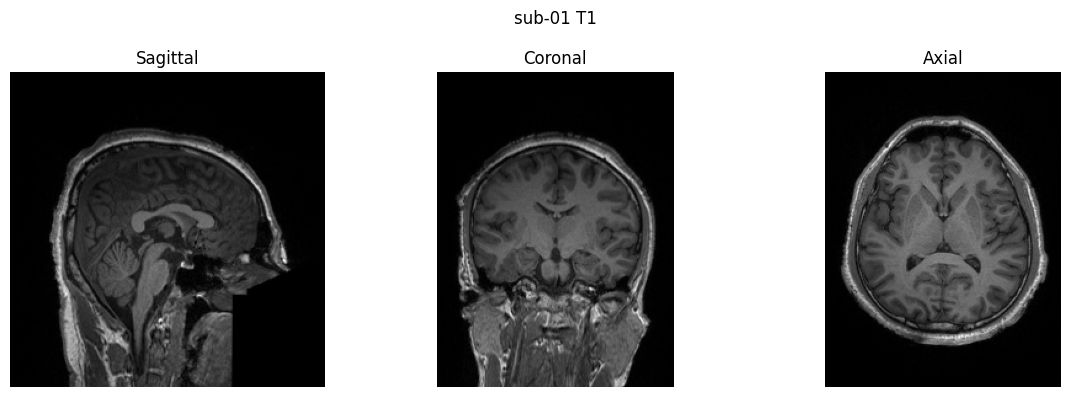

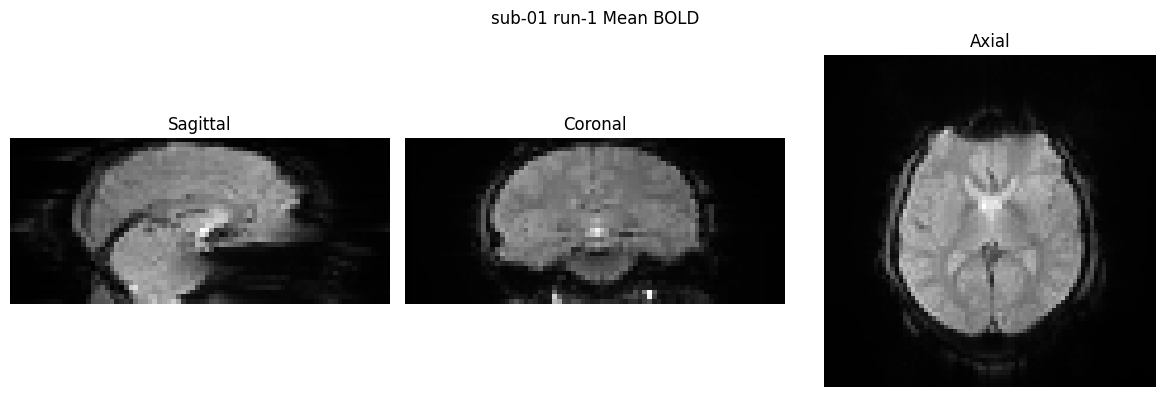

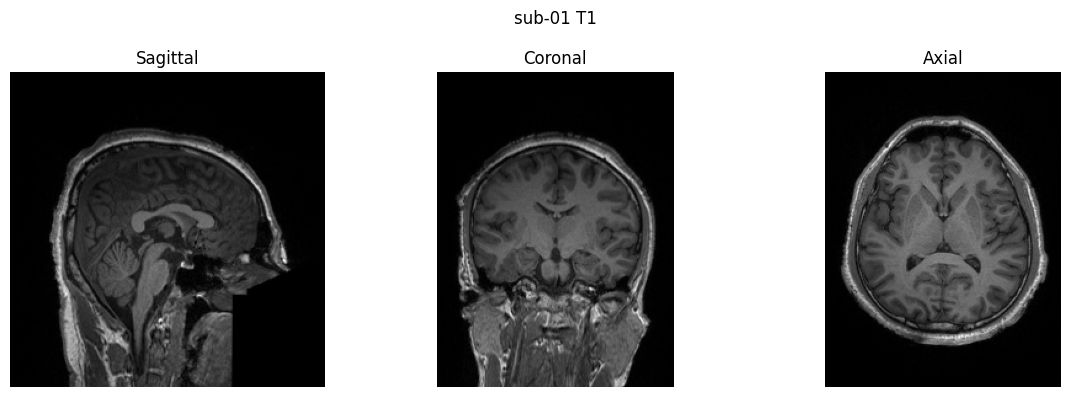

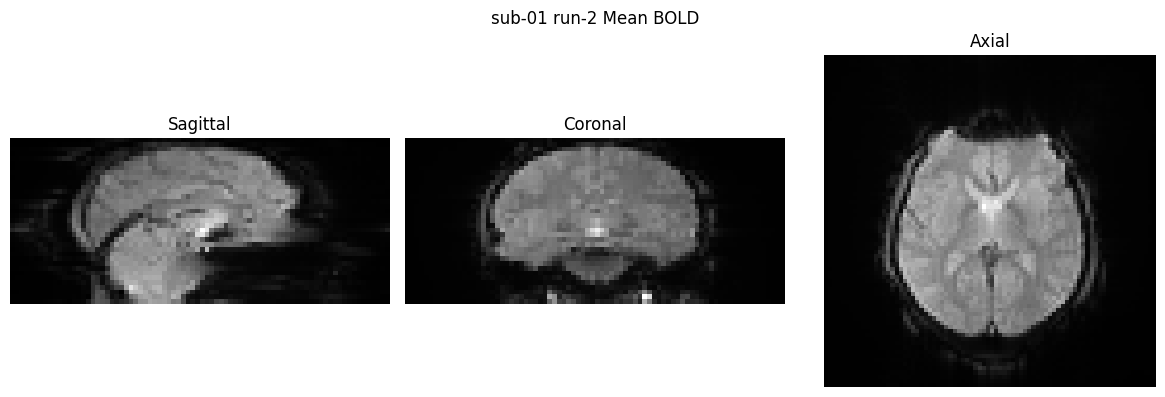

Mean-BOLD & QC figures created for both runs.


In [6]:
# Generate mean-BOLD and QC imgs (both run)

for spec in run_specs:
    t1_nii = Path(spec["inputs"]["t1_nii"])
    bold_nii = Path(spec["inputs"]["bold_nii"])
    mean_bold_path = Path(spec["derived_inputs"]["mean_bold"])
    t1_qc_png = Path(spec["outputs"]["t1_qc_png"])
    mean_bold_qc_png = Path(spec["outputs"]["mean_bold_qc_png"])

    save_mean_bold(bold_nii, mean_bold_path)

    t1_img = nib.load(str(t1_nii))
    mean_bold_img = nib.load(str(mean_bold_path))

    plot_orthogonal(t1_img.get_fdata(), title=f"{spec['subject']} T1", out_png=t1_qc_png)
    plot_orthogonal(mean_bold_img.get_fdata(), title=f"{spec['subject']} {spec['run']} Mean BOLD", out_png=mean_bold_qc_png)

print("Mean-BOLD & QC figures created for both runs.")

In [7]:
# Prepare BOLD imgs

def prepare_bold_for_spm(spec: dict):
    """
    Copy/gunzip the original bold into the run-specific SPM working directory.
    We do this so SPM writes outputs into the analysis folder, not the raw data folder.
    """
    bold_nii = Path(spec["inputs"]["bold_nii"])
    spm_run_dir = Path(spec["outputs"]["spm_run_dir"])

    spm_run_dir.mkdir(parents=True, exist_ok=True)

    local_gz = spm_run_dir / bold_nii.name
    local_nii = spm_run_dir / bold_nii.name.replace(".nii.gz", ".nii")

    if not local_gz.exists():
        shutil.copy2(bold_nii, local_gz)

    if not local_nii.exists():
        import gzip
        with gzip.open(local_gz, "rb") as f_in, open(local_nii, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    return {
        "local_gz": str(local_gz),
        "local_nii": str(local_nii),
    }

# Reading volume list
def make_spm_volume_list(nii_path: Path):
    """
    Build ['file.nii,1', 'file.nii,2', ...] for all 4D volumes.
    """
    img = nib.load(str(nii_path))
    shape = img.shape
    assert len(shape) == 4, f"Expected 4D BOLD, got {shape}"
    nvol = shape[3]
    return [f"{nii_path},{i}" for i in range(1, nvol + 1)]

# Define realign flags
def make_realign_flags():
    flags = Struct()
    flags.quality = 0.9
    flags.sep = 4.0
    flags.fwhm = 5.0
    flags.rtm = 1
    flags.interp = 2
    flags.wrap = np.array([0, 0, 0], dtype=float)
    flags.weight = ''
    return flags

def make_reslice_flags():
    flags = Struct()
    flags.which = np.array([2, 1], dtype=float)
    flags.interp = 4
    flags.wrap = np.array([0, 0, 0], dtype=float)
    flags.mask = 1
    flags.prefix = 'r'
    return flags

In [13]:
# Initializing :: 기존 파일 삭제
# for spec in run_specs:
#     run_dir = Path(spec["outputs"]["spm_run_dir"])
#     for p in run_dir.glob("rp_*.txt"):
#         p.unlink()

#     motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
#     if motion_tsv.exists():
#         motion_tsv.unlink()

In [14]:
# Execution

def run_spm_realign_trial(spec: dict, execute: bool = False, show_qc: bool = True):
    result = {
        "subject": spec["subject"],
        "run": spec["run"],
        "execute": execute,
        "success": False,
        "prepared_local_files": None,
        "generated_files": {},
        "qc_files": {},
        "error": None,
    }

    try:
        spm_run_dir = Path(spec["outputs"]["spm_run_dir"])
        qc_run_dir = Path(spec["outputs"]["qc_run_dir"])
        qc_run_dir.mkdir(parents=True, exist_ok=True)

        prepared = prepare_bold_for_spm(spec)
        local_nii = Path(prepared["local_nii"])
        local_gz = Path(prepared["local_gz"])
        result["prepared_local_files"] = prepared

        scans = make_spm_volume_list(local_nii)

        # --- Before images ---
        pre_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_before_realign.nii.gz"
        save_mean_bold(local_nii, pre_mean_path)

        # Dry-run: only confirm preparation + save pre mean
        if not execute:
            img = nib.load(str(local_nii))
            result["success"] = True
            result["generated_files"] = {
                "local_gz": str(local_gz),
                "local_nii": str(local_nii),
                "n_scans": int(img.shape[3]),
                "mean_before_realign": str(pre_mean_path),
            }
            return result

        # --- Realign + Reslice ---
        realign_flags = make_realign_flags()
        reslice_flags = make_reslice_flags()

        # let SPM write rp_*.txt itself
        spm_realign(scans, realign_flags, nargout=0)
        spm_reslice(scans, reslice_flags)

        # --- Discover outputs ---
        generated = {}
        generated["local_gz"] = str(local_gz)
        generated["local_nii"] = str(local_nii)
        generated["realigned_files"] = sorted([str(p) for p in spm_run_dir.glob("r*.nii")])
        generated["mean_files"] = sorted([str(p) for p in spm_run_dir.glob("mean*.nii")])

        # Standard output copy for downstream use
        if len(generated["realigned_files"]) == 1:
            src = Path(generated["realigned_files"][0])
            dst = Path(spec["outputs"]["spm_preproc_bold"])
            save_as_nii_or_niigz(src, dst)
            generated["standard_preproc_bold"] = str(dst)

        # motion parameter file discovery + standard TSV save
        rp_candidates = sorted(spm_run_dir.glob("rp_*.txt"))
        generated["motion_files_txt"] = [str(p) for p in rp_candidates]

        if len(rp_candidates) == 1:
            rp_txt = rp_candidates[0]
            motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])

            df_motion = pd.read_csv(rp_txt, sep=r"\s+", header=None)
            df_motion.columns = ["x", "y", "z", "pitch", "roll", "yaw"]
            df_motion.to_csv(motion_tsv, sep="\t", index=False)

            generated["standard_motion_tsv"] = str(motion_tsv)
            generated["motion_n_rows"] = int(df_motion.shape[0])
        else:
            generated["standard_motion_tsv"] = None
            generated["motion_error"] = f"Expected 1 rp_*.txt file, found {len(rp_candidates)}"

        # --- QC images ---
        qc_files = {}

        # 1) Realign before/after:
        # compare mean of original local BOLD vs mean image produced after reslice
        post_mean_path = None
        if len(generated["mean_files"]) == 1:
            post_mean_path = Path(generated["mean_files"][0])

            realign_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_realign_before_after.png"
            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_mean_path,
                title=f"{spec['subject']} {spec['run']} - Realign: Before vs After",
                out_png=realign_compare_png
            )
            qc_files["realign_before_after_png"] = str(realign_compare_png)

        # 2) Reslice before/after:
        # for practical QC here, compare original local mean vs realigned 4D output mean
        if "standard_preproc_bold" in generated:
            standard_preproc_bold = Path(generated["standard_preproc_bold"])
            post_reslice_mean_path = spm_run_dir / f"{spec['subject']}_{spec['run']}_mean_after_reslice.nii.gz"
            save_mean_bold(standard_preproc_bold, post_reslice_mean_path)

            reslice_compare_png = qc_run_dir / f"{spec['subject']}_{spec['run']}_reslice_before_after.png"
            plot_before_after_orthogonal(
                before_img_path=pre_mean_path,
                after_img_path=post_reslice_mean_path,
                title=f"{spec['subject']} {spec['run']} - Reslice: Before vs After",
                out_png=reslice_compare_png
            )
            qc_files["mean_after_reslice"] = str(post_reslice_mean_path)
            qc_files["reslice_before_after_png"] = str(reslice_compare_png)

        # 3) Optional single-image views
        if show_qc:
            if pre_mean_path.exists():
                plot_orthogonal(
                    nib.load(str(pre_mean_path)).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean Before Realign"
                )
            if len(generated["mean_files"]) == 1:
                plot_orthogonal(
                    nib.load(generated["mean_files"][0]).get_fdata(),
                    title=f"{spec['subject']} {spec['run']} Mean After Realign"
                )

        result["generated_files"] = generated
        result["qc_files"] = qc_files
        result["success"] = True
        return result

    except Exception:
        result["error"] = traceback.format_exc()
        return result


realign_trial_dry_results = []
for spec in run_specs:
    res = run_spm_realign_trial(spec, execute=False)
    realign_trial_dry_results.append(res)

realign_trial_dry_results

[{'subject': 'sub-01',
  'run': 'run-1',
  'execute': False,
  'success': True,
  'prepared_local_files': {'local_gz': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii.gz',
   'local_nii': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii'},
  'generated_files': {'local_gz': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii.gz',
   'local_nii': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii',
   'n_scans': 286,
   'mean_before_realign': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_run-1_mean_before_realign.nii.gz'},
  'qc_files': {},
  'error': None},
 {'subject': 'sub-01',
  'run': 'run-2',
  'execute': False,
  'success': True,
  'prepared_local_

In [15]:
#### Execute realignment (both runs)

realign_trial_exec_results = []
for spec in run_specs:
    res = run_spm_realign_trial(spec, execute=True)
    realign_trial_exec_results.append(res)

realign_trial_exec_results


SPM25: spm_realign                                 18:02:07 - 13/04/2026

SPM25: spm_realign                                 18:02:07 - 13/04/2026


Dot indexing is not supported for variables of this type.

Error in spm_realign>realign_series (line 188)

Error in spm_realign (line 127)

Error in mpython_endpoint (line 19)

Dot indexing is not supported for variables of this type.

Error in spm_realign>realign_series (line 188)

Error in spm_realign (line 127)

Error in mpython_endpoint (line 19)



[{'subject': 'sub-01',
  'run': 'run-1',
  'execute': True,
  'success': False,
  'prepared_local_files': {'local_gz': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii.gz',
   'local_nii': '/media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01/run-1/sub-01_task-rest_run-1_bold.nii'},
  'generated_files': {},
  'qc_files': {},
  'error': 'Traceback (most recent call last):\n  File "/tmp/ipykernel_1447899/435933395.py", line 48, in run_spm_realign_trial\n    spm_realign([scans], realign_flags, nargout=0)\n  File "/home/bami/anaconda3/envs/JHA-spmCVR/lib/python3.10/site-packages/spm/spm_realign.py", line 97, in spm_realign\n    return Runtime.call("spm_realign", *args, **kwargs)\n  File "/home/bami/anaconda3/envs/JHA-spmCVR/lib/python3.10/site-packages/mpython/runtime.py", line 45, in call\n    res = cls.instance().mpython_endpoint(fn, *args, **kwargs)\n  File "/home/bami/anaconda3/envs/J

In [11]:
for spec in run_specs:
    motion_tsv = Path(spec["outputs"]["spm_motion_tsv"])
    df_mot = pd.read_csv(motion_tsv, sep="\t")
    print(f"\n===== {spec['subject']} {spec['run']} =====")
    print("shape:", df_mot.shape)
    print(df_mot)


===== sub-01 run-1 =====
shape: (1, 6)
     x    y    z  pitch  roll  yaw
0  0.0  0.0  0.0    0.0   0.0  0.0

===== sub-01 run-2 =====
shape: (1, 6)
     x    y    z  pitch  roll  yaw
0  0.0  0.0  0.0    0.0   0.0  0.0


In [12]:
for spec in run_specs:
    run_dir = Path(spec["outputs"]["spm_run_dir"])
    rp_files = sorted(run_dir.glob("rp_*.txt"))
    print(f"\n===== {spec['subject']} {spec['run']} =====")
    for rp in rp_files:
        print("file:", rp.name)
        with open(rp, "r") as f:
            lines = f.readlines()
        print("n_lines:", len(lines))
        print("first 3 lines:")
        for line in lines[:3]:
            print(line.rstrip())


===== sub-01 run-1 =====
file: rp_sub-01_task-rest_run-1_bold.txt
n_lines: 1
first 3 lines:
   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00

===== sub-01 run-2 =====
file: rp_sub-01_task-rest_run-2_bold.txt
n_lines: 1
first 3 lines:
   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00   0.0000000e+00


In [10]:
for spec in run_specs:
    run_dir = Path(spec["outputs"]["spm_run_dir"])
    print(f"\n===== {spec['subject']} {spec['run']} =====")
    for p in sorted(run_dir.iterdir()):
        print(p.name)


===== sub-01 run-1 =====
meansub-01_task-rest_run-1_bold.nii
rsub-01_task-rest_run-1_bold.nii
sub-01_run-1_mean_before_realign.nii.gz
sub-01_run-1_mean_bold.nii.gz
sub-01_run-1_part5_trial_result.json
sub-01_run-1_preproc_bold.nii.gz
sub-01_run-1_preproc_config.json
sub-01_run-1_realign_job.m
sub-01_run-1_realign_trial_spec.json
sub-01_run-1_spm_test_spec.json
sub-01_run-1_spm_wrapper_test.json
sub-01_task-rest_run-1_bold.nii
sub-01_task-rest_run-1_bold.nii.gz

===== sub-01 run-2 =====
meansub-01_task-rest_run-2_bold.nii
rsub-01_task-rest_run-2_bold.nii
sub-01_run-2_mean_before_realign.nii.gz
sub-01_run-2_mean_bold.nii.gz
sub-01_run-2_preproc_bold.nii.gz
sub-01_run-2_realign_job.m
sub-01_task-rest_run-2_bold.nii
sub-01_task-rest_run-2_bold.nii.gz


In [11]:
for spec in run_specs:
    run_dir = Path(spec["outputs"]["spm_run_dir"])
    print(f"\n===== {spec['subject']} {spec['run']} : candidate motion files =====")
    
    candidates = []
    for pattern in ["*.txt", "*.tsv", "rp_*", "*motion*", "*.mat"]:
        candidates.extend(run_dir.glob(pattern))
    
    candidates = sorted(set(candidates))
    for p in candidates:
        print(p.name)


===== sub-01 run-1 : candidate motion files =====

===== sub-01 run-2 : candidate motion files =====


In [12]:
for spec in run_specs:
    raw_dir = Path(spec["inputs"]["bold_nii"]).parent
    print(f"\n===== {spec['subject']} {spec['run']} : raw input dir =====")
    
    candidates = []
    for pattern in ["rp_*", "*.txt", "*motion*", "*.mat"]:
        candidates.extend(raw_dir.glob(pattern))
    
    candidates = sorted(set(candidates))
    for p in candidates:
        print(p.name)


===== sub-01 run-1 : raw input dir =====

===== sub-01 run-2 : raw input dir =====


In [13]:
sub_root = Path(run_specs[0]["outputs"]["spm_subject_root"])

print(f"Searching under: {sub_root}\n")

candidates = []
for pattern in ["rp_*", "*.txt", "*motion*", "*.mat"]:
    candidates.extend(sub_root.rglob(pattern))

for p in sorted(set(candidates)):
    print(p)

Searching under: /media/bami/JHA/rsCVR/data/OpenNeuro/rsCVR_Results/M01_ds003768/spm_preproc/sub-01



In [14]:
summary_rows = []

for spec in run_specs:
    run_dir = Path(spec["outputs"]["spm_run_dir"])
    
    realigned = sorted(run_dir.glob("r*.nii"))
    means = sorted(run_dir.glob("mean*.nii"))
    txts = sorted(run_dir.glob("*.txt"))
    mats = sorted(run_dir.glob("*.mat"))
    
    summary_rows.append({
        "subject": spec["subject"],
        "run": spec["run"],
        "n_rnii": len(realigned),
        "n_mean": len(means),
        "n_txt": len(txts),
        "n_mat": len(mats),
        "realigned_files": [p.name for p in realigned],
        "mean_files": [p.name for p in means],
        "txt_files": [p.name for p in txts],
        "mat_files": [p.name for p in mats],
    })

df_motion_check = pd.DataFrame(summary_rows)
df_motion_check

,subject,run,n_rnii,n_mean,n_txt,n_mat,realigned_files,mean_files,txt_files,mat_files
0,sub-01,run-1,1,1,0,0,[rsub-01_task-rest_run-1_bold.nii],[meansub-01_task-rest_run-1_bold.nii],[],[]
1,sub-01,run-2,1,1,0,0,[rsub-01_task-rest_run-2_bold.nii],[meansub-01_task-rest_run-2_bold.nii],[],[]


In [ ]:
# Save results
part6_results = {
    "subject": TEST_SUBJECT,
    "dry_results": realign_trial_dry_results,
    "exec_results": realign_trial_exec_results,
    "timestamp": datetime.now().isoformat(),
}
part6_json = SUMMARY_DIR / f"{TEST_SUBJECT}_part6_realign_results.json"
save_json(part6_results, part6_json)

part6_json

In [ ]:
print("SUMMARY:::: ")
print("Test subject              :", TEST_SUBJECT)
print("Runs tested               :", TEST_RUNS)
print("All dry-runs successful   :", all(x["success"] for x in realign_trial_dry_results))
print("Execution successes       :", [x["success"] for x in realign_trial_exec_results])
print("Part6 JSON                :", part6_json)
print("Part6 summary CSV         :", part6_summary_csv)

In [ ]:
# Summarise per run

summary_rows = []

for res in realign_trial_exec_results:
    summary_rows.append({
        "subject": res["subject"],
        "run": res["run"],
        "success": res["success"],
        "returncode": res["returncode"],
        "n_realigned_spm_dir": len(res["generated_files"].get("realigned_files", [])),
        "n_mean_spm_dir": len(res["generated_files"].get("mean_files", [])),
        "n_motion_spm_dir": len(res["generated_files"].get("motion_files_txt", [])),
        "n_realigned_input_dir": len(res["generated_files"].get("input_dir_realigned_files", [])),
        "n_mean_input_dir": len(res["generated_files"].get("input_dir_mean_files", [])),
        "n_motion_input_dir": len(res["generated_files"].get("input_dir_motion_files_txt", [])),
    })
df_part6_summary = pd.DataFrame(summary_rows)

df_part6_summary

In [ ]:
# Save summary
part6_summary_csv = SUMMARY_DIR / f"{TEST_SUBJECT}_part6_realign_summary.csv"

df_part6_summary.to_csv(part6_summary_csv, index=False)
part6_summary_csv